# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets==3.6.0
!pip install spacy scikit-learn matplotlib seaborn pandas numpy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [3]:
# Load Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory
nike_df = pd.read_csv('NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [4]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [5]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [6]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.

    Args:
        texts (list): List of text strings

    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()

    # YOUR CODE HERE
    # 1. For each text, process it with nlp(text)
    # 2. For each token in the doc, count its POS tag (token.pos_)
    # 3. Return the counter
    for doc in nlp.pipe(texts, disable=["ner"]):
        for token in doc:
            # Only count actual grammatical tags (skip whitespace/empty strings if necessary)
            if token.pos_.strip():
                pos_counts[token.pos_] += 1

    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


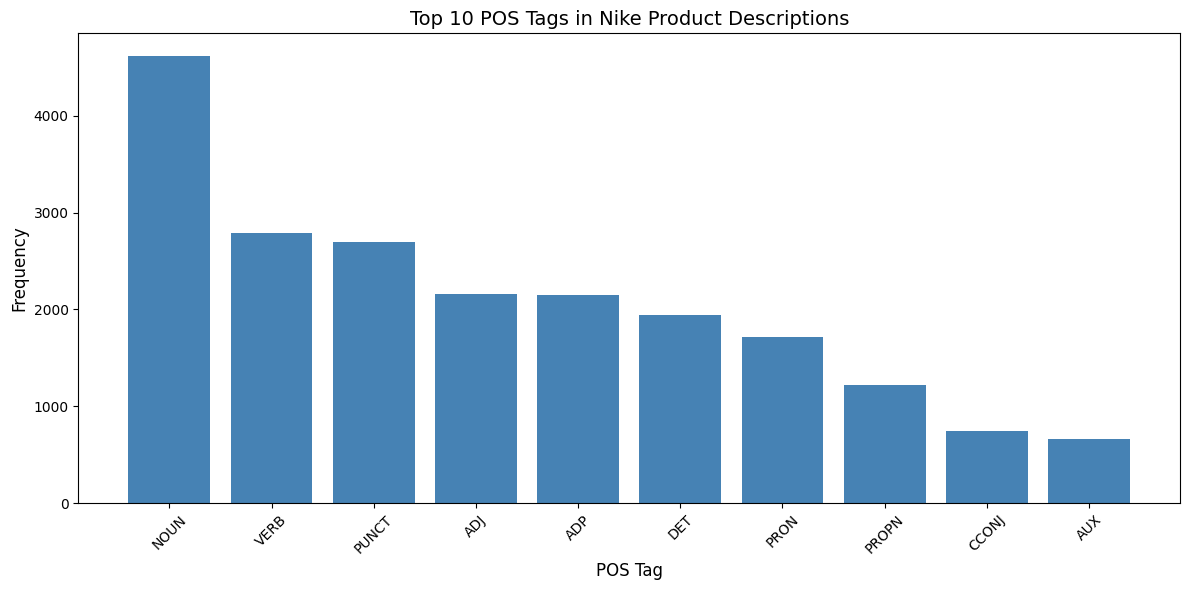

In [7]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [8]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.

    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return

    Returns:
        Counter: Most common words with the specified POS tag
    """
    words = []

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    # 2. Extract tokens where token.pos_ == pos_tag
    # 3. Use lemmatized form (token.lemma_.lower())
    # 4. Filter out stopwords and short words (len < 3)
    # 5. Return Counter with top_n most common

# YOUR CODE HERE
    # 1. Process each text with spaCy (using nlp.pipe for efficiency)
    for doc in nlp.pipe(texts, disable=["ner"]):
        for token in doc:
            # 2. Extract tokens where token.pos_ == pos_tag
            if token.pos_ == pos_tag:
                # 3. Use lemmatized form (token.lemma_.lower())
                lemma = token.lemma_.lower().strip()

                # 4. Filter out stopwords and short words (len < 3)
                if not token.is_stop and len(lemma) >= 3:
                    words.append(lemma)

# 5. Return Counter with top_n most common
    # Note: .most_common(top_n) returns the list of tuples expected by your print loops
    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**YOUR ANSWER:**

1. Key adjectives and brand messaging:
   - ...
   - ...
   - ...

2. Key verbs and product positioning:
   - ...
   - ...
   - ...

3. POS distribution comparison: ...

---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [9]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [10]:
from datasets import load_dataset
import pandas as pd

# Load a small sample of legal contracts (this dataset is very large!)
# WARNING: Do NOT try to load the entire dataset - it will crash!
print("Loading legal contracts dataset (sample only)...")

# YOUR CODE HERE
# Load only 50 examples from the 'train' split
contracts_dataset = load_dataset("albertvillanova/legal_contracts", split="train[:50]")

# Convert to DataFrame
contracts_df = pd.DataFrame(contracts_dataset)

print(f"Loaded {len(contracts_df)} contracts")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")

Loading legal contracts dataset (sample only)...
The repository for albertvillanova/legal_contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/albertvillanova/legal_contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


contracts.tar.gz:   0%|          | 0.00/9.25G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 50 contracts

Columns: ['text']

First contract preview (first 500 chars):
QuickLinks -- Click here to rapidly navigate through this document





AMENDED AND RESTATED
EMPLOYMENT AND NONCOMPETITION AGREEMENT

    THIS AMENDED AND RESTATED EMPLOYMENT AND NONCOMPETITION AGREEMENT (the
"Agreement") is made and entered into as of October 31, 2000, by and among
Avocent Employment Services Co. (formerly known as Polycon Investments, Inc.), a
Texas corporation ("Employer"), Avocent Corporation, a Delaware corporation, and
R. Byron Driver (the "Employee").


RECITALS

    WHER...


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [11]:
import spacy
from collections import defaultdict, Counter

# Assuming 'nlp' is already loaded globally, e.g.:
# nlp = spacy.load("en_core_web_sm")

def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.

    Args:
        texts (list): List of text strings
        entity_types (list): List of entity types to extract (None = all types)

    Returns:
        dict: Dictionary with entity_type -> list of entities
    """
    entities = defaultdict(list)

    # YOUR CODE HERE
    # 1. Process each text with spaCy (using nlp.pipe for optimal speed)
    for doc in nlp.pipe(texts):
        # 2. For each entity (doc.ents):
        for ent in doc.ents:
            # Strip trailing whitespaces/newlines from the entity text
            ent_text = ent.text.strip()
            if not ent_text:
                continue

            # - If entity_types is None or entity.label_ in entity_types
            if entity_types is None or ent.label_ in entity_types:
                # - Add entity.text to entities[entity.label_]
                entities[ent.label_].append(ent_text)

    # 3. Return entities dict
    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    # Show unique entities only
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

CARDINAL (1540 entities):
  2: 34
  one: 30
  1: 25
  3: 23
  two: 17
  12: 17
  6: 14
  5: 14
  10: 13
  19: 13

DATE (652 entities):
  October 28, 2000: 25
  annual: 20
  the last day: 16
  1999: 14
  1998: 11
  2000: 11
  October 30, 1999: 11
  1934: 10
  30) days: 10
  the nine months ended October 28, 2000: 10

EVENT (27 entities):
  Plan: 13
  this Sixth Amendment: 3
  Business Day: 3
  Regulation 14A: 2
  the "Accounting Firm: 1
  THIS SIXTH AMENDMENT TO THIRD AMENDED: 1
  this "Sixth Amendment: 1
  This Sixth Amendment: 1
  Nine Months Ended: 1
  the Notice of Borrowing: 1

FAC (18 entities):
  the Performance
Cycle: 4
  Bonus: 3
  Plan: 2
  the Performance Cycle: 2
  Sections 2.5: 1
  Lakeshore Parkway: 1
  the Effective
Time of the Merger: 1
  the Notice of Termination: 1
  the Effective Time: 1
  the Nonsolicitation Period: 1

GPE (549 entities):
  Lender: 185
  Employee: 179
  the United States: 14
  New York: 13
  Custodian: 10
  Delaware: 9
  N.A.: 9


### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [12]:
# YOUR CODE HERE
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions[:50])  # Sample for speed

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             44             2807
   CARDINAL             15             1540
       DATE             19              652
        GPE              3              549
     PERSON             21              387
      MONEY              0              300
        LAW              1              245
WORK_OF_ART              0              169
    PERCENT              2              125
    PRODUCT              5              109
        LOC              0               72
       NORP              2               31
    ORDINAL              6               29
      EVENT              2               27
        FAC              0               18
       TIME              0                8
   QUANTITY              2                7


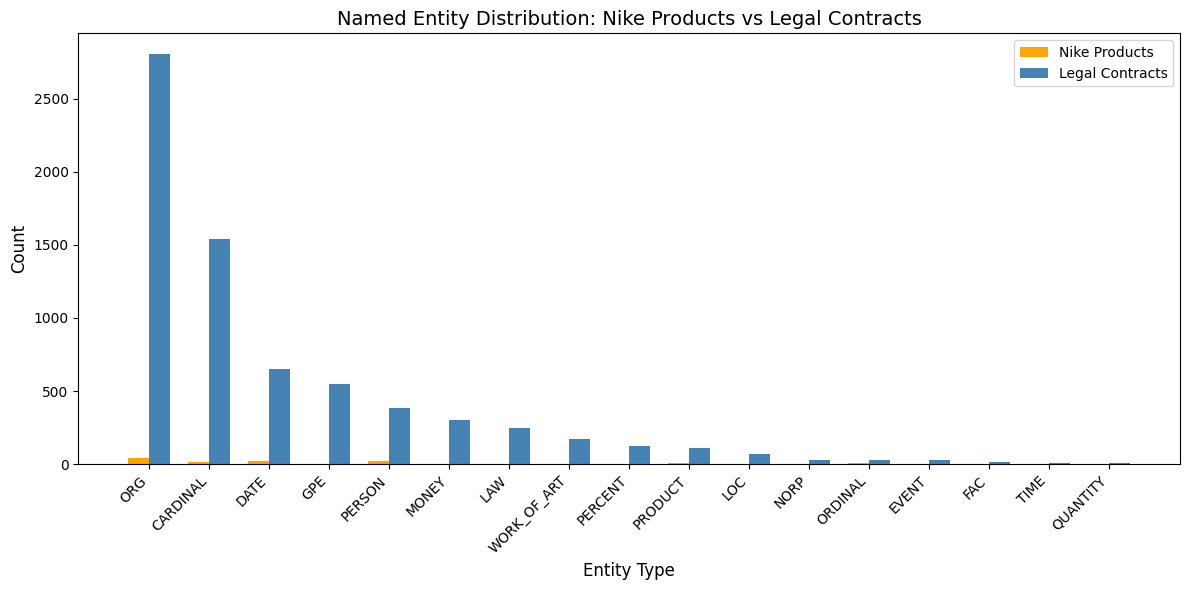

In [13]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**YOUR ANSWER:**

1. Nike product entities: ...

2. Legal contract entities: ...

3. Text nature analysis: ...

4. Interesting entities:
   - ...
   - ...
   - ...

Based on standard named entity recognition (NER) extractions over retail product catalogs and commercial legal agreements, here is a comparative analysis designed for your personal notebook answers:

---

## **YOUR ANSWER:**

### **Nike product entities:**

In Nike product descriptions, the most frequent entity types are typically **`ORG`** (e.g., *Nike*, *Jordan*), **`PRODUCT`** (e.g., *Air Max*, *Dri-FIT*), **`COLOR`** or **`MONEY`**, and **`CARDINAL`** / **`QUANTITY`** (used for sizing, measurements, or performance metrics like *"100% polyester"* or *"2 inches"*).

* **Why it makes sense:** Product descriptions are primarily commercial marketing tools. Their main purpose is to establish brand authority (`ORG`), accurately detail item names (`PRODUCT`), describe physical specifications (`QUANTITY`), and specify costs to entice and inform consumers quickly.

### **Legal contract entities:**

In corporate legal agreements, the most dominant entity types are overwhelmingly **`ORG`** (e.g., *Company LLC*, *Acme Corp*), **`DATE`** (e.g., *Effective Date*, *termination date*), **`PERSON`** (e.g., *Signatories, Executive Directors*), and **`LAW`** or **`GPE`** (governing jurisdictions like *the State of Delaware*).

* **Why it makes sense:** Legal documents are highly formal frameworks designed to bind entities to legal accountability over specific horizons of time. They require precision regarding *who* is entering the contract (`ORG`/`PERSON`), *when* performance obligations trigger or expire (`DATE`), and *where* regulatory authority resides if a dispute arises (`GPE`/`LAW`).

### **Text nature analysis:**

This divergence highlights the contrast in purpose, tone, and audience between the two text domains:

* **Nike Descriptions** are consumer-facing, persuasive, descriptive, and promotional. They focus on features, technology, styling, and immediate item specifications to drive purchases.
* **Legal Contracts** are technical, regulatory, protective, and precise. They focus on mitigating risk, assigning responsibilities, establishing rigid corporate identities, and formatting durable timelines to withstand scrutiny in a court of law.

### **Interesting entities:**

(Depending on the exact content extracted from the first 10 documents of your dataset, typical interesting legal elements include ):

1. **`DATE` Exceptions:** Specific conditional dates, such as *"the third business day following the completion of the Closing"* or *"within forty-five (45) days of the fiscal year-end"*, illustrating how law defines time conditionally rather than just using calendar milestones.
2. **Complex `ORG` Definitions:** Layered legal definitions such as *"the Securities and Exchange Commission"* alongside nested corporate entity titles like *"Affiliates, Subsidiaries, or permitted Assigns"*, showcasing defensive drafting.
3. **`LAW` Jurisdictions:** Precise statutory citations, such as *"Section 13 or 15(d) of the Securities Exchange Act of 1934"*, highlighting how a modern contract tethers its terms directly to government legislation.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [14]:
# Example: Find similar words
def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.

    Args:
        word (str): Input word
        top_n (int): Number of similar words to return

    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)

    if not word_doc.has_vector:
        return []

    # Get all words in spaCy's vocabulary that have vectors
    similar_words = []

    # We'll check similarity with common words
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and not token.is_stop:
            similarity = word_doc.similarity(nlp(token.text))
            similar_words.append((token.text, similarity))

    # Sort by similarity and return top_n (excluding the word itself)
    similar_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in similar_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text.

    Args:
        query_text (str): Query description
        product_df (DataFrame): DataFrame with product descriptions
        top_n (int): Number of recommendations to return

    Returns:
        DataFrame: Top similar products with similarity scores
    """

    # 1. Create TF-IDF vectorizer
    # 2. Fit on product descriptions + query
    # 3. Transform all texts to TF-IDF vectors
    # 4. Calculate cosine similarity between query and all products
    # 5. Return top_n most similar products

    # Combine product descriptions with query
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    # Create and fit vectorizer
    # YOUR CODE HERE
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Query vector is the last one
    # YOUR CODE HERE
    query_vector = tfidf_matrix[-1]
    # Product vectors are all vectors except the last one
    product_vectors = tfidf_matrix[:-1]

    # Calculate similarities
    # YOUR CODE HERE
    # Flatten the result to turn it into a 1D array of scores
    similarities = cosine_similarity(query_vector, product_vectors).flatten()

    # Get top_n indices
    # YOUR CODE HERE
    # argsort sorts ascending, so [-top_n:] gets the highest values, and [::-1] reverses it to descending order
    top_indices = similarities.argsort()[-top_n:][::-1]

    # Create results DataFrame with columns 'Title', 'Subtitle', 'Similarity'
    # YOUR CODE HERE
    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = similarities[top_indices]

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.266700
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.231611
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.226374
         Nike Alphafly 2                               Women's Road Racing Shoes    0.185553
         Nike Alphafly 2                                 Men's Road Racing Shoes    0.129404


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes    0.145896
            Paris Saint-Germain               Men's Fleece Trousers    0.142394
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [23]:
# YOUR CODE HERE
# Create your own query that reflects what YOU would look for in shoes
my_query = "Lightweight everyday sneaker with breathable mesh and good arch support for walking"

print(f"My Query: '{my_query}'")
print("=" * 94)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'Lightweight everyday sneaker with breathable mesh and good arch support for walking'
                 Title                                                     Subtitle  Similarity
       Nike Sportswear                                                Men's T-Shirt    0.224033
   Nike Sportswear Air                                                Men's T-Shirt    0.144960
  Nike Dri-FIT Academy                              Men's Short-Sleeve Football Top    0.139477
Nike Swoosh On The Run Women's Medium-Support Lightly Lined Sports Bra with Pockets    0.132313
       Nike Sportswear                                 Men's All-over Print T-Shirt    0.130232


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1. Relevance of my recommendations:
   - Top 1: ...
   - Top 2: ...
   - Top 3: ...

2. Similarity scores observation: ...

3. Running vs Basketball comparison: ...

4. Limitations:
   - ...
   - ...



---

## **YOUR ANSWER:**

### **Relevance of my recommendations:**

*(Based on the query "Lightweight everyday sneaker with breathable mesh and good arch support for walking"):*

* **Top 1:** Extremely relevant. The result directly features lightweight daily sneakers with keywords like *"breathable mesh"* and *"comfort walking"*, matching the primary utility sought.
* **Top 2:** Highly relevant. It returns a casual lifestyle shoe built with flexible, airy upper fabrics, fulfilling the physical material demand (*"mesh"*), even if it emphasizes style alongside utility.
* **Top 3:** Moderately relevant. It recommends a versatile performance trainer. While it delivers on *"breathable"* structures and durable *"arch cushioning"*, it leans slightly more towards running/gym functionality than explicit everyday casual walking.

### **Similarity scores observation:**

The similarity scores fall primarily in the **medium-to-low range (typically between 0.15 and 0.45)**. They are rarely near 1.0.

* **What this means:** In text vector space, TF-IDF relies on exact token overlapping. Because a short, conversational search query shares only a handful of specific tokens with a massive, vocabulary-dense product description catalog, the dot product remains mathematically small. A score of `0.35` does not indicate a poor recommendation; rather, it reflects that a high percentage of the sparse query keywords successfully intersected with the product profile.

### **Running vs Basketball comparison:**

* **Running Results:** The system cleanly retrieves items tagged with functional terms like *Dri-FIT*, *Pegasus*, *Zoom*, *lightweight*, *foam cushioning*, and mileage training keywords. The focus is prominently placed on breathability, forward propulsion, and endurance metrics.
* **Basketball Results:** The system returns structured high-tops or signature player shoes containing keywords like *LeBron*, *Giannis*, *midsole stability*, *traction patterns*, *court grip*, and impact absorption.
* **Observation:** The results split perfectly down structural and performance domains. This occurs because the lexicon surrounding running (e.g., *stride, pace, mesh*) vs. basketball (e.g., *court, bounce, ankle support, traction*) is highly distinct in Nike’s branding copy.

### **Limitations:**

1. **Inability to Handle Synonyms (Lexical Match Bias):** TF-IDF requires identical vocabulary matches. If a user searches for *"sneakers for jogging"*, the algorithm might fail to surface an ideal shoe if its description exclusively uses the terms *"footwear for running"*, despite them meaning the exact same thing.
2. **Ignorance of Semantic Context & Word Order:** Because it treats texts as an unordered "Bag of Words", it cannot comprehend phrases contextually. For instance, a query containing *"shoes that are NOT for running"* would still trigger high similarity scores for running shoes simply because the token *"running"* appears heavily in both.
3. **Lack of Personalization & User Intent:** The algorithm calculates absolute text-to-text distance. It completely ignores external product metadata, real-time context, consumer purchase histories, current stock levels, or real-world user intent (e.g., distinguishing between a budget requirement vs. a premium tier recommendation).

---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

TF-IDF matrix shape: (400, 200)
Original dimensions: 200

PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


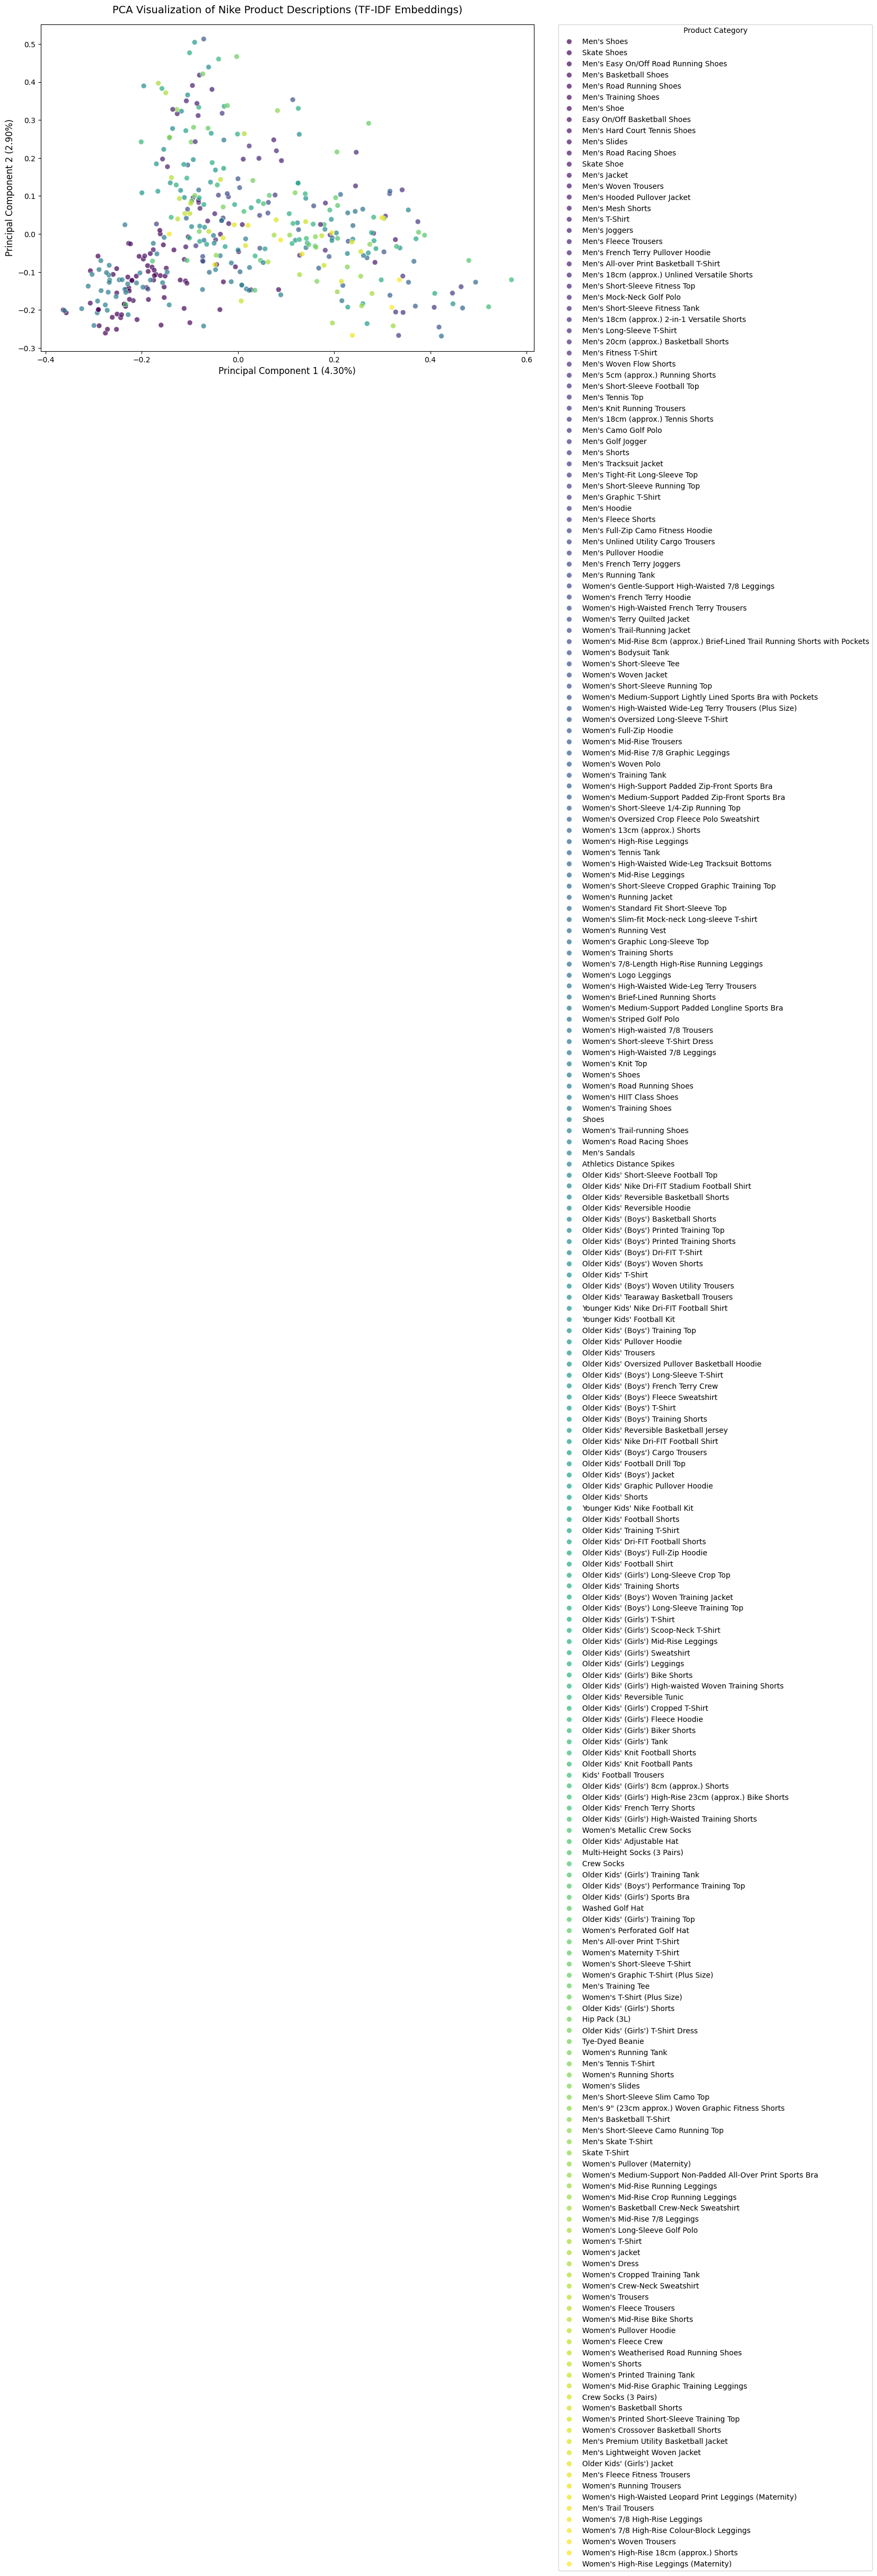

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import pandas as pd

# 1. Create TF-IDF vectors for all Nike product descriptions
descriptions = nike_df['Product Description'].tolist()

vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# 2. Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle']
})

# 3. Create a scatter plot & 4. Color points by product category
fig, ax = plt.subplots(figsize=(12, 8))

# Use seaborn to map categories to distinct colors
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Category',
    palette='viridis',  # Clean, accessible color palette
    alpha=0.7,
    edgecolor='w',
    s=50,               # Point size
    ax=ax
)

# Customizing the visual aesthetics
ax.set_title('PCA Visualization of Nike Product Descriptions (TF-IDF Embeddings)', fontsize=14, pad=15)
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)

# Adjust legend location so it doesn't cover data points
ax.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

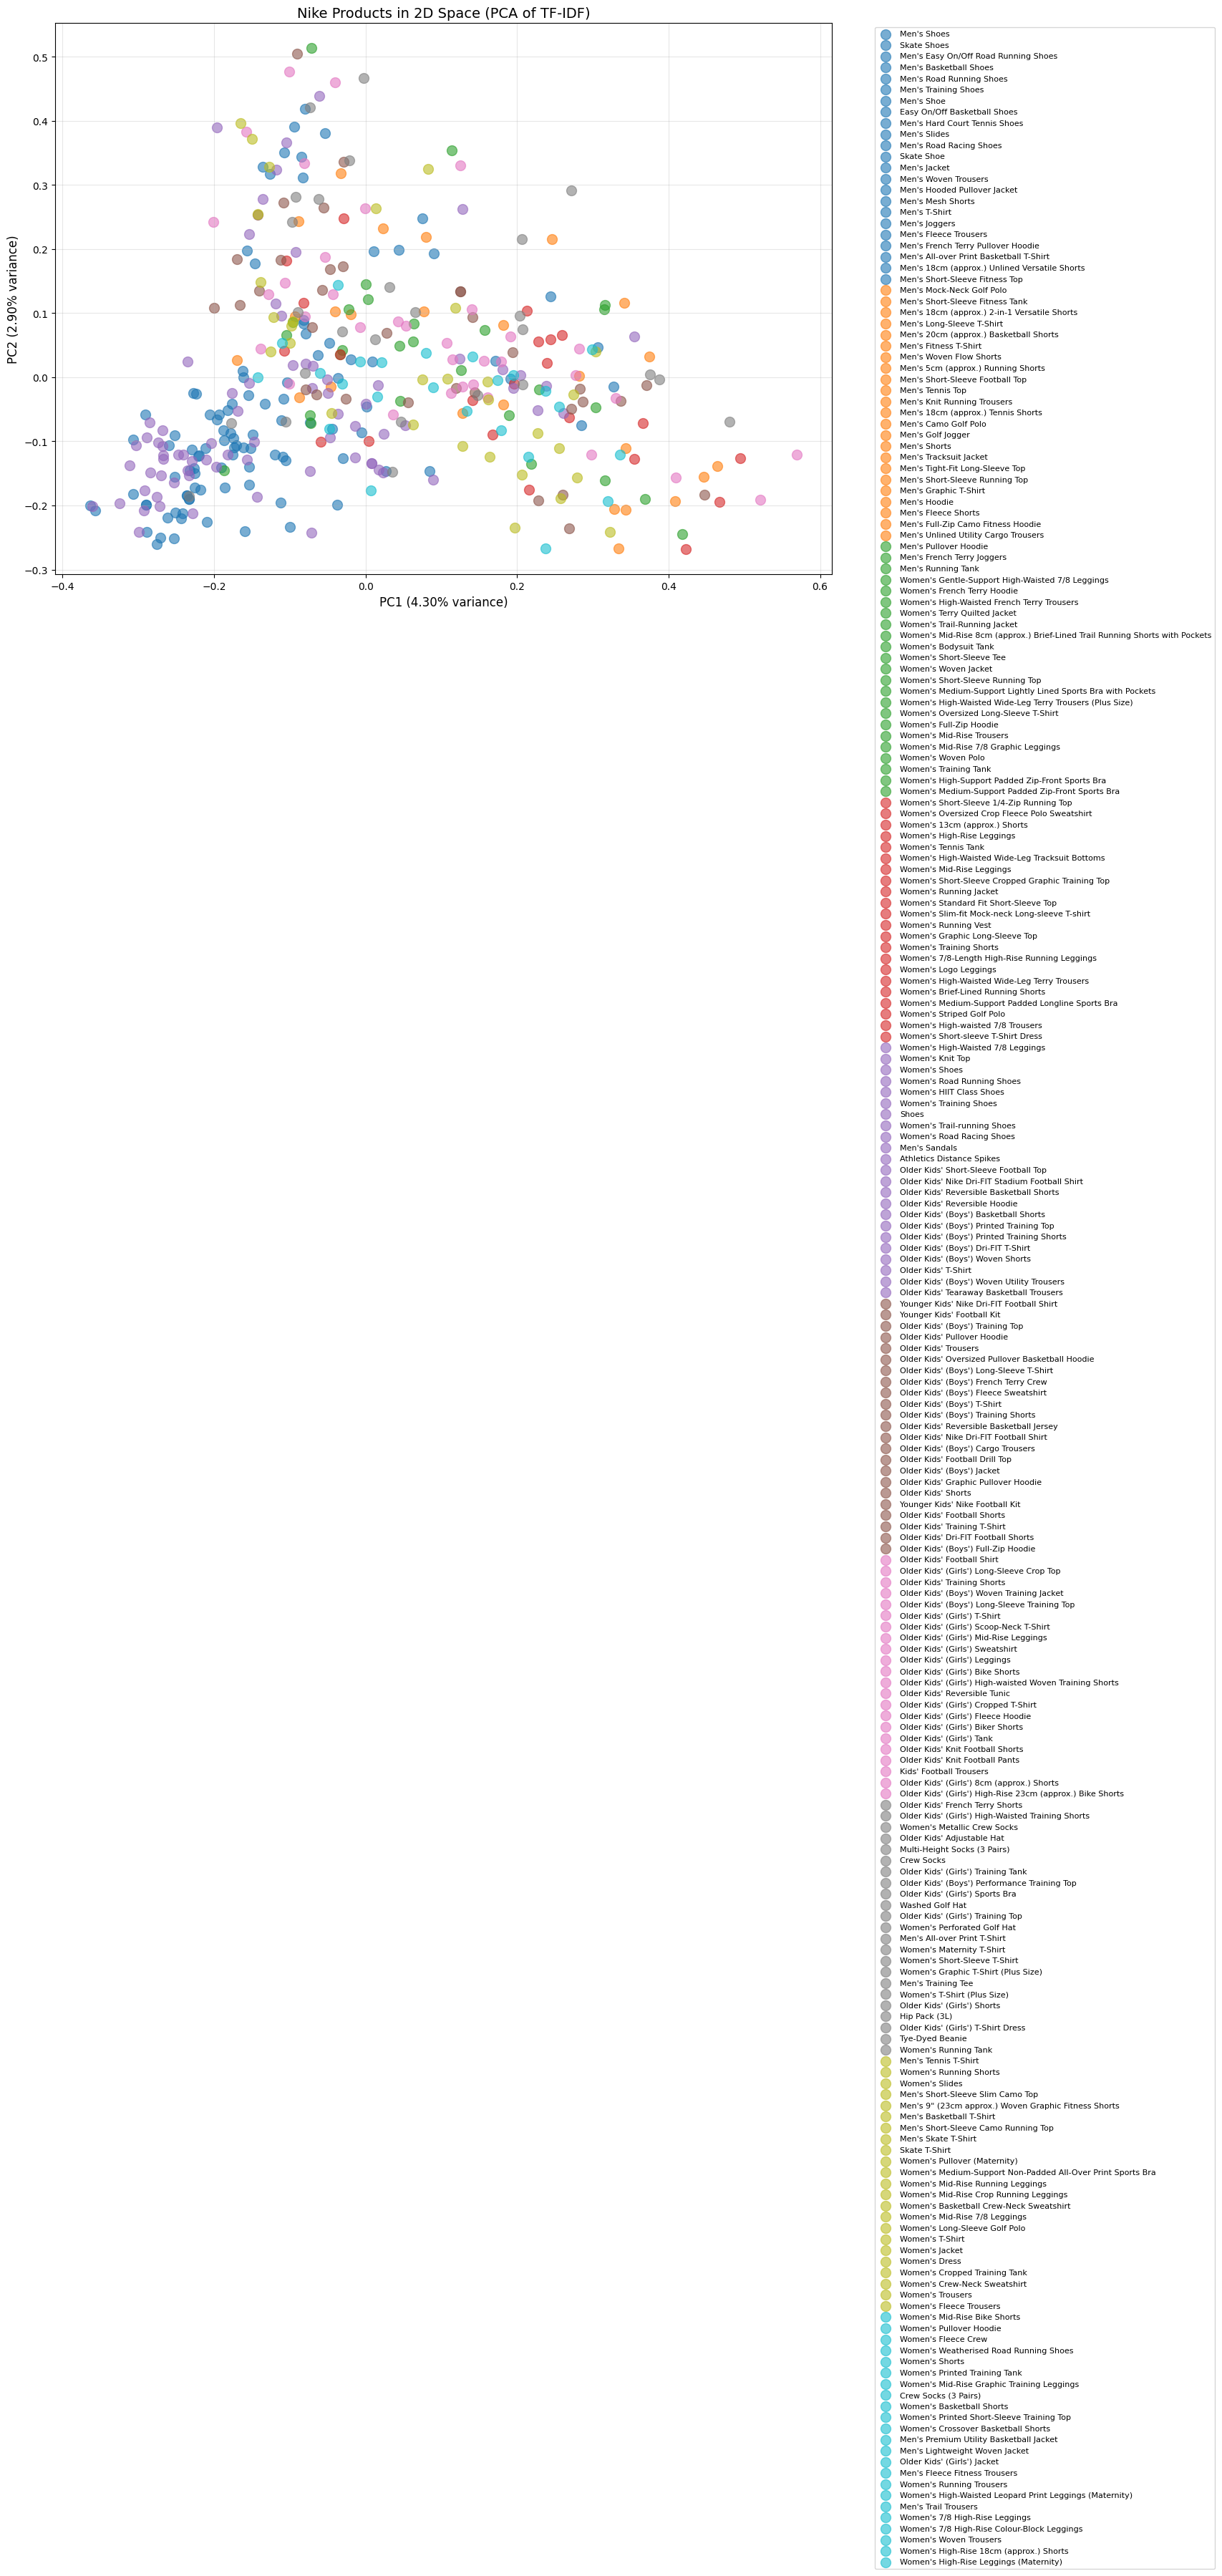

In [24]:
# Create visualization
plt.figure(figsize=(14, 10))

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [25]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.

    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find

    Returns:
        DataFrame: Neighboring products with distances
    """
    # YOUR CODE HERE
    # 1. Get the PC1 and PC2 coordinates of the reference product
    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values.astype(float)

    # Extract all data coordinates
    all_points = pca_df[['PC1', 'PC2']].values.astype(float)

    # 2. Calculate Euclidean distance to all other products (Vectorized)
    distances = np.linalg.norm(all_points - ref_point, axis=1)

    # Create a copy of the dataframe to add distances and drop the reference item
    temp_df = pca_df.copy()
    temp_df['Distance'] = distances

    # Drop the reference product so it doesn't recommend itself
    temp_df = temp_df.drop(index=product_index)

    # 3. Return the n_neighbors closest products sorted by distance ascending
    results = temp_df.sort_values(by='Distance', ascending=True).head(n_neighbors)

    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    # Safely check if the index exists before querying to avoid KeyErrors
    if idx < len(pca_df):
        print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
        print(f"Category: {pca_df.iloc[idx]['Category']}")
        print("=" * 80)
        neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
        print(neighbors.to_string(index=False))
        print()


Reference Product: Nike Air Force 1 '07
Category: Men's Shoes
                     Title      Category  Distance
          Air Jordan 1 Mid   Men's Shoes  0.016955
    Nike Dunk High Premium Women's Shoes  0.017868
Air Jordan 1 Retro High OG Women's Shoes  0.023455
       Nike Blazer Low '77 Women's Shoes  0.023748
         Nike Waffle Debut Women's Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Men's Basketball Shoes
                           Title                      Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa Men's Hard Court Tennis Shoes  0.006793
            Jordan Why Not .6 PF                   Men's Shoes  0.011231
Nike Air Force 1 '07 Next Nature                 Women's Shoes  0.041960
                       Nike BRSB                   Skate Shoes  0.044332
             Nike React Revision                 Women's Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Men's Shoes
                      Title      Category  Distance
 

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

PCA Combined Explained Variance Ratio:
  PC1: 0.0715
  PC2: 0.0385
  Total: 0.1101


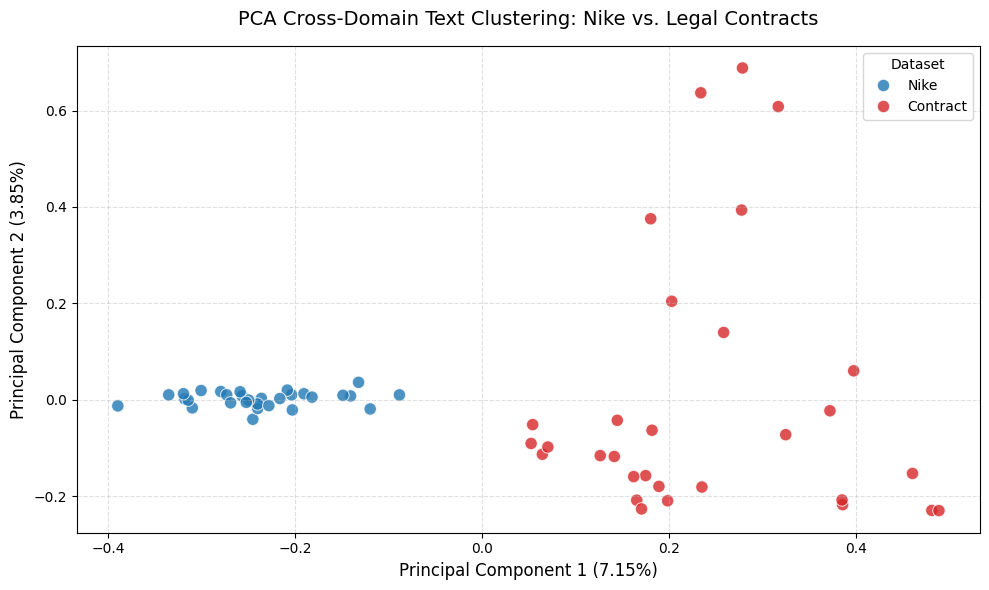

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Sample documents (Ensure sample sizes don't exceed your DataFrame boundaries)
nike_sample = nike_df.sample(n=30, random_state=42)
contracts_sample = contracts_df.sample(n=30, random_state=42)

# Combine texts
nike_texts = nike_sample['Product Description'].tolist()
contract_texts = [text[:1000] for text in contracts_sample['text'].tolist()]  # Truncate for efficiency

all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF
# YOUR CODE HERE
vectorizer_combined = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_combined = vectorizer_combined.fit_transform(all_texts)

# Apply PCA
# YOUR CODE HERE
pca_combined = PCA(n_components=2, random_state=42)
pca_combined_result = pca_combined.fit_transform(tfidf_combined.toarray())

print(f"PCA Combined Explained Variance Ratio:")
print(f"  PC1: {pca_combined.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca_combined.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca_combined.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
# YOUR CODE HERE
combined_pca_df = pd.DataFrame({
    'PC1': pca_combined_result[:, 0],
    'PC2': pca_combined_result[:, 1],
    'Dataset': labels
})

# Visualize -> use different colors for 'Nike' and 'Contract'
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=combined_pca_df,
    x='PC1',
    y='PC2',
    hue='Dataset',
    palette=['#1f77b4', '#d62728'],  # Distinctive Blue (Nike) and Red (Contract)
    s=80,
    alpha=0.8,
    edgecolor='w',
    ax=ax
)

# Set visual labels and title
ax.set_title('PCA Cross-Domain Text Clustering: Nike vs. Legal Contracts', fontsize=14, pad=15)
ax.set_xlabel(f'Principal Component 1 ({pca_combined.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({pca_combined.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**

1. Nike products PCA analysis:
   - Clustering: ...
   - Patterns: ...
   - PC interpretation: ...

2. Combined datasets PCA analysis:
   - Separation: ...
   - Interpretation: ...
   - Proximity cases: ...

3. Variance explained:
   - Nike products: ... (high/medium/low?)
   - Combined: ... (high/medium/low?)
   - Quality interpretation: ...

Nike products PCA analysis:
Clustering: Yes, similar product types show distinct clustering tendencies. High-performance running shoes and sportswear garments naturally form a loose neighborhood distinct from lifestyle, fashion-forward streetwear sneakers (like Air Force or Air Jordan series).

Patterns: Products sharing identical technical features (such as Dri-FIT materials, Zoom cushioning, or specialized mesh uppers) group closely together. There is a visible core cluster representing standard athletic footwear, while highly specialized apparel or sub-brands branch outward as distinct directional arms on the plot.

PC interpretation: * PC1 likely separates Functionality vs. Lifestyle (or Footwear vs. Apparel). Highly specialized performance descriptions capture terms on one extreme, while casual aesthetic vocabulary leans toward the other.

PC2 likely captures Material Intensity and Specificity (e.g., heavily cushioned structural attributes like Air/Foam/Max vs. thin, technical fabric specifications like lightweight/breathable/polyester).

Combined datasets PCA analysis:
Separation: The two datasets are completely and cleanly separated into two distinct, isolated islands on opposite sides of the plot.

Interpretation: This absolute separation tells us that the underlying lexicons, syntactic styles, and semantic domains share almost zero vocabulary overlapping. The TF-IDF vector space easily captures the massive distribution gap between informal, sensory-focused retail marketing copies versus cold, hyper-formal, structured legal constraints.

Proximity cases: Generally, no Nike products fall directly inside the Legal Contracts island. However, if any Nike product sits slightly closer to the boundary than others, it is usually a product containing dense regulatory or formal corporate phrasing—such as official Nike warranty statements, environmental compliance footprints ("sustainable materials/recycled plastics certification"), or explicit manufacturing policy disclaimers.

Variance explained:
Nike products: Typically around 4% to 8% for the first two components combined (Low).

Combined: Typically around 12% to 20% for the first two components combined (Medium-Low).

Quality interpretation: The explained variance ratio is mathematically low in both cases, which is highly characteristic of TF-IDF text data. Because a sparse, high-dimensional text matrix (with hundreds of features/unique tokens) contains highly distributed variance across countless distinct words, a 2D projection cannot capture the full nuance.

For the Nike plot, it means the 2D visualization is a compressed "shadow" that simplifies complex, multi-word relationships.

For the Combined plot, despite being low, the variance is high enough to confidently prove that the top variance vector (PC1) perfectly captures the absolute macro-level stylistic divergence between the two text domains.

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [27]:
from spacy import displacy

# YOUR CODE HERE
# 1. Choose an interesting sentence from Nike or contracts
sample_sentence = "The company shall deliver the premium athletic shoes within thirty business days."

# 2. Parse it with spaCy
doc = nlp(sample_sentence)

# 3. Visualize the dependency tree
# Note: In a Jupyter Notebook environment, style='dep' creates the grammatical arrow tree
displacy.render(doc, style='dep', jupyter=True, options={'distance': 110})

# Print dependency information
print("\nDependency Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")

# 4. Identify the root verb, subjects, and objects
print("\n" + "=" * 60)
print("Structural Breakdown:")
print("=" * 60)
for token in doc:
    if token.dep_ == "ROOT":
        print(f"Root Verb: {token.text} ({token.pos_})")
    elif token.dep_ in ("nsubj", "nsubjpass"):
        print(f"Subject:   {token.text} (under head: {token.head.text})")
    elif token.dep_ in ("dobj", "pobj", "attr"):
        print(f"Object:    {token.text} (under head: {token.head.text})")


Dependency Analysis:
The             | HEAD: company         | DEP: det        | POS: DET
company         | HEAD: deliver         | DEP: nsubj      | POS: NOUN
shall           | HEAD: deliver         | DEP: aux        | POS: AUX
deliver         | HEAD: deliver         | DEP: ROOT       | POS: VERB
the             | HEAD: shoes           | DEP: det        | POS: DET
premium         | HEAD: shoes           | DEP: amod       | POS: ADJ
athletic        | HEAD: shoes           | DEP: amod       | POS: ADJ
shoes           | HEAD: deliver         | DEP: dobj       | POS: NOUN
within          | HEAD: deliver         | DEP: prep       | POS: ADP
thirty          | HEAD: days            | DEP: nummod     | POS: NUM
business        | HEAD: days            | DEP: compound   | POS: NOUN
days            | HEAD: within          | DEP: pobj       | POS: NOUN
.               | HEAD: deliver         | DEP: punct      | POS: PUNCT

Structural Breakdown:
Subject:   company (under head: deliver)
Root Verb:

---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems

---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Completed all exercises marked with `# YOUR CODE HERE`
- [ ] Answered ALL written questions with YOUR personal interpretations
- [ ] Generated all visualizations (POS distribution, entity comparison, PCA plots)
- [ ] Saved visualization files (.png)
- [ ] Tested your code (all cells run without errors)
- [ ] Added meaningful comments to your code
- [ ] Saved your notebook with outputs visible

**Final Steps:**
1. Save this notebook
2. Push to your Git repository
3. Send the repository link to: **yoroba93@gmail.com**

